# Model Analysis — Training Data from Supabase

In [20]:
import sys, os, tomllib
import pandas as pd
from supabase import create_client

# Load secrets from .streamlit/secrets.toml
_secrets_path = os.path.join(os.path.dirname(os.getcwd()), "new_bike_day", ".streamlit", "secrets.toml")
# Walk up to repo root regardless of cwd
_repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
_secrets_path = os.path.join(_repo_root, ".streamlit", "secrets.toml")
with open(_secrets_path, "rb") as f:
    secrets = tomllib.load(f)

supabase = create_client(secrets["SUPABASE_URL"], secrets["SUPABASE_KEY"])
print("Connected to Supabase ✓")

Connected to Supabase ✓


In [21]:
def _fetch_all(table: str) -> pd.DataFrame:
    """Paginate through a Supabase table and return all rows as a DataFrame."""
    PAGE = 1000
    rows, start = [], 0
    while True:
        page = supabase.table(table).select("*").range(start, start + PAGE - 1).execute()
        batch = page.data or []
        rows.extend(batch)
        if len(batch) < PAGE:
            break
        start += PAGE
    return pd.DataFrame(rows)

rides          = _fetch_all("rides")
segment_efforts = _fetch_all("segment_efforts")
bikes          = _fetch_all("bikes")
ftp            = _fetch_all("athlete_ftp")
segments       = _fetch_all("starred_segments")

print(f"rides:           {len(rides):,} rows")
print(f"segment_efforts: {len(segment_efforts):,} rows")
print(f"bikes:           {len(bikes):,} rows")
print(f"ftp:             {len(ftp):,} rows")
print(f"segments:        {len(segments):,} rows")

rides:           2,609 rows
segment_efforts: 8,797 rows
bikes:           18 rows
ftp:             3 rows
segments:        91 rows


In [22]:
import sys, types
from pathlib import Path

# Add repo root so src imports work
_repo_root = str(Path(os.getcwd()).parent)
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

# Stub out streamlit + every submodule that src/ imports from it,
# before any src import runs so sys.modules picks up the stubs.
def _noop_decorator(*a, **kw):
    return (lambda fn: fn)

_st = types.ModuleType("streamlit")
_st.cache_resource = _noop_decorator
_st.cache_data = _noop_decorator
_st.secrets = secrets  # real values so database.py can build its Supabase client

_st_runtime = types.ModuleType("streamlit.runtime")
_st_scriptrunner = types.ModuleType("streamlit.runtime.scriptrunner")
_st_scriptrunner.get_script_run_ctx = lambda: None
_st_runtime.scriptrunner = _st_scriptrunner
_st.runtime = _st_runtime

for _name, _mod in [
    ("streamlit", _st),
    ("streamlit.runtime", _st_runtime),
    ("streamlit.runtime.scriptrunner", _st_scriptrunner),
]:
    sys.modules.setdefault(_name, _mod)

from src.bike_delta import prepare_delta_dataset, engineer_features, XGB_SPEED_FEATURES, XGB_WATT_FEATURES
from src.analytics import filter_outliers_by_power_speed, apply_min_watts_filter

print("Imports OK")

Imports OK


In [23]:
# Build bikes_dict: {gear_id → bike_name} — what prepare_delta_dataset expects
bikes_dict = dict(zip(bikes["gear_id"], bikes["name"]))
print("Bikes:", bikes_dict)

raw_df = prepare_delta_dataset(
    efforts_df=segment_efforts,
    segments_df=segments,
    bikes_dict=bikes_dict,
    min_watts=0,
)
print(f"prepare_delta_dataset → {len(raw_df):,} rows, {raw_df.shape[1]} cols")

# filter_outliers_by_power_speed returns (filtered, annotated)
raw_df, _ = filter_outliers_by_power_speed(raw_df, z_threshold=2.5)
print(f"After outlier filter   → {len(raw_df):,} rows")

# Engineer XGBoost features
df = engineer_features(raw_df)
print(f"After engineer_features → {len(df):,} rows, {df.shape[1]} cols")
print("\nBike counts:")
print(df["bike_name"].value_counts())

Bikes: {'b13987132': ':))', 'b10727211': 'Aspero Apex 1', 'b12593556': 'Bianchi boardwalk', 'b15894471': 'Canyon Aeroad CF SLX', 'b18369682': 'Blue citi bike', 'b7369117': 'Fastback', 'b11695366': 'Habanero ', 'b15829864': 'Drew bike', 'b7576250': 'Titanium Horse', 'b13934125': 'Tr*k Madone', 'b12809160': 'Track bike rental ', 'b14499703': 'Fixed gear', 'b18111244': 'Marinoni ', 'b17974179': 'Specialized Tarmac SL8', 'b11922954': 'Featherweight', 'b14356886': 'Glizzy', 'b16392809': '🐻 Smokey 🐻 ', 'b15485762': '👁️👁️🔥'}
prepare_delta_dataset → 6,586 rows, 25 cols
After outlier filter   → 6,502 rows
After engineer_features → 6,502 rows, 57 cols

Bike counts:
bike_name
Aspero Apex 1             2746
Canyon Aeroad CF SLX      1775
Specialized Tarmac SL8     808
Titanium Horse             461
:))                        404
Habanero                   258
Drew bike                   32
Tr*k Madone                 18
Name: count, dtype: int64


In [37]:
from src.plots import make_fig_b_sc
from IPython.display import display, HTML

ref_bike = "Canyon Aeroad CF SLX"
Z_THRESH = 1.5
TOP_N    = 3

_pre_filter = prepare_delta_dataset(
    efforts_df=segment_efforts,
    segments_df=segments,
    bikes_dict=bikes_dict,
    min_watts=0,
)
_pre_filter = apply_min_watts_filter(_pre_filter, 180, descents_exempt=True)
_, annotated = filter_outliers_by_power_speed(_pre_filter, z_threshold=Z_THRESH)

bdata = annotated[annotated["bike_name"] == ref_bike].copy()
if "z_label" not in bdata.columns:
    bdata["z_label"] = bdata["z_score"].map(lambda z: f"{z:.2f}" if z == z else "")

print(f"Bike: {ref_bike}  |  total: {len(bdata):,}  |  removed: {bdata['is_outlier'].sum():,} ({bdata['is_outlier'].mean():.1%})")

top_segs = (
    bdata.groupby("segment_id")["effort_id"].count()
    .sort_values(ascending=False)
    .head(TOP_N)
    .index.tolist()
)

for sid in top_segs:
    seg    = bdata[bdata["segment_id"] == sid].copy()
    grade  = seg["average_grade"].mean()
    n      = len(seg)

    spw    = seg.dropna(subset=["speed_per_cbrt_watt"])
    b_mean = spw["speed_per_cbrt_watt"].mean()
    b_std  = spw["speed_per_cbrt_watt"].std()
    b_lo   = b_mean - Z_THRESH * b_std
    b_hi   = b_mean + Z_THRESH * b_std

    fig = make_fig_b_sc(
        bike_color="#1f77b4",
        bdata=seg,
        spd="km/h",
        z_threshold=Z_THRESH,
        b_lo=b_lo,
        b_hi=b_hi,
        b_mean=b_mean,
    )
    fig.update_layout(
        title=f"Segment {sid} — grade {grade:.1f}%  n={n}  |  {ref_bike}  (min 180 W, descents exempt)",
        # height=400,
        margin={"t": 50, "b": 10},

    )
    display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))

Bike: Canyon Aeroad CF SLX  |  total: 1,625  |  removed: 205 (12.6%)


In [ ]:
from src.bike_delta import (
    fit_xgb_speed_model,
    apply_model_to_bike,
    fit_xgb_watt_model,
    apply_watt_model_to_bike,
    XGB_PARAMS,
    XGB_SPEED_FEATURES,
    XGB_WATT_FEATURES,
)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

print("Modeling functions imported ✓")
print(f"XGB_SPEED_FEATURES ({len(XGB_SPEED_FEATURES)}):", XGB_SPEED_FEATURES)
print(f"\nXGB_WATT_FEATURES ({len(XGB_WATT_FEATURES)}):", XGB_WATT_FEATURES)
print("\nDefault XGB_PARAMS:", XGB_PARAMS)

Modeling functions imported ✓
XGB_SPEED_FEATURES (17): ['average_watts', 'average_grade', 'maximum_grade', 'doy_sin', 'doy_cos', 'log_watts', 'watts_per_grade', 'distance_km', 'heartrate', 'effort_count', 'woy_cos', 'month_sin', 'month_cos', 'cbrt_watts', 'woy_sin', 'straightness_index', 'segtype_descent']

XGB_WATT_FEATURES (22): ['speed_kmh', 'average_grade', 'maximum_grade', 'doy_sin', 'doy_cos', 'distance_km', 'heartrate', 'effort_count', 'woy_cos', 'month_sin', 'month_cos', 'woy_sin', 'log_speed', 'cbrt_speed', 'straightness_index', 'segtype_descent', 'speed_per_grade', 'elapsed_ratio', 'segtype_detail_descent_steep', 'segtype_detail_sprint_uphill', 'segtype_sprint', 'segtype_detail_sprint_flat']

Default XGB_PARAMS: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'random_state': 42, 'verbosity': 0}


In [ ]:
# Per-bike speed model stats — random 80/20 split
MIN_EFFORTS = 500

rows = []
models = {}

eligible_bikes = (
    df.dropna(subset=XGB_SPEED_FEATURES + ["speed_kmh"])
    .groupby("bike_name")
    .size()
    .loc[lambda s: s >= MIN_EFFORTS]
    .sort_values(ascending=False)
    .index.tolist()
)

for bike in eligible_bikes:
    bike_df = df[df["bike_name"] == bike].dropna(subset=XGB_SPEED_FEATURES + ["speed_kmh"])
    train, test = train_test_split(bike_df, test_size=0.2, random_state=42)

    model = fit_xgb_speed_model(train, bike)
    models[bike] = model

    y_test = test["speed_kmh"].values
    y_hat  = model.predict(test[XGB_SPEED_FEATURES])

    rows.append({
        "bike":       bike,
        "n_train":    len(train),
        "n_test":     len(test),
        "R²":         round(r2_score(y_test, y_hat), 3),
        "RMSE km/h":  round(mean_squared_error(y_test, y_hat) ** 0.5, 3),
        "MAE km/h":   round(mean_absolute_error(y_test, y_hat), 3),
        "mean_speed": round(bike_df["speed_kmh"].mean(), 2),
    })

stats = pd.DataFrame(rows)
print(f"Per-bike speed model stats (random 80/20 split, min {MIN_EFFORTS} efforts):")
print(stats.to_string(index=False))

# now for watts
rows = []
models = {}
eligible_bikes = (
    df.dropna(subset=XGB_WATT_FEATURES + ["average_watts"])
    .groupby("bike_name")
    .size()
    .loc[lambda s: s >= MIN_EFFORTS]
    .sort_values(ascending=False)
    .index.tolist()
)

for bike in eligible_bikes:
    bike_df = df[df["bike_name"] == bike].dropna(subset=XGB_WATT_FEATURES + ["average_watts"])
    train, test = train_test_split(bike_df, test_size=0.2, random_state=42)

    model = fit_xgb_watt_model(train, bike)
    models[bike] = model

    y_test = test["average_watts"].values
    y_hat  = model.predict(test[XGB_WATT_FEATURES])

    rows.append({
        "bike":       bike,
        "n_train":    len(train),
        "n_test":     len(test),
        "R²":         round(r2_score(y_test, y_hat), 3),
        "RMSE watts":  round(mean_squared_error(y_test, y_hat) ** 0.5, 3),
        "MAE watts":   round(mean_absolute_error(y_test, y_hat), 3),
        "mean_watts": round(bike_df["average_watts"].mean(), 2),
    })

stats = pd.DataFrame(rows)
print(f"Per-bike watt model stats (random 80/20 split, min {MIN_EFFORTS} efforts):")
print(stats.to_string(index=False))

Per-bike speed model stats (random 80/20 split, min 500 efforts):
                  bike  n_train  n_test    R²  RMSE km/h  MAE km/h  mean_speed
  Canyon Aeroad CF SLX      992     249 0.936      1.699     1.236       29.35
         Aspero Apex 1      912     229 0.943      2.074     1.501       31.35
Specialized Tarmac SL8      438     110 0.979      1.526     1.071       30.56
Per-bike watt model stats (random 80/20 split, min 500 efforts):
                  bike  n_train  n_test    R²  RMSE watts  MAE watts  mean_watts
  Canyon Aeroad CF SLX      992     249 0.902      26.582     16.893      248.73
         Aspero Apex 1      912     229 0.836      38.391     26.546      237.30
Specialized Tarmac SL8      438     110 0.891      39.692     22.050      202.88


SHAP analysis on: 'Canyon Aeroad CF SLX'


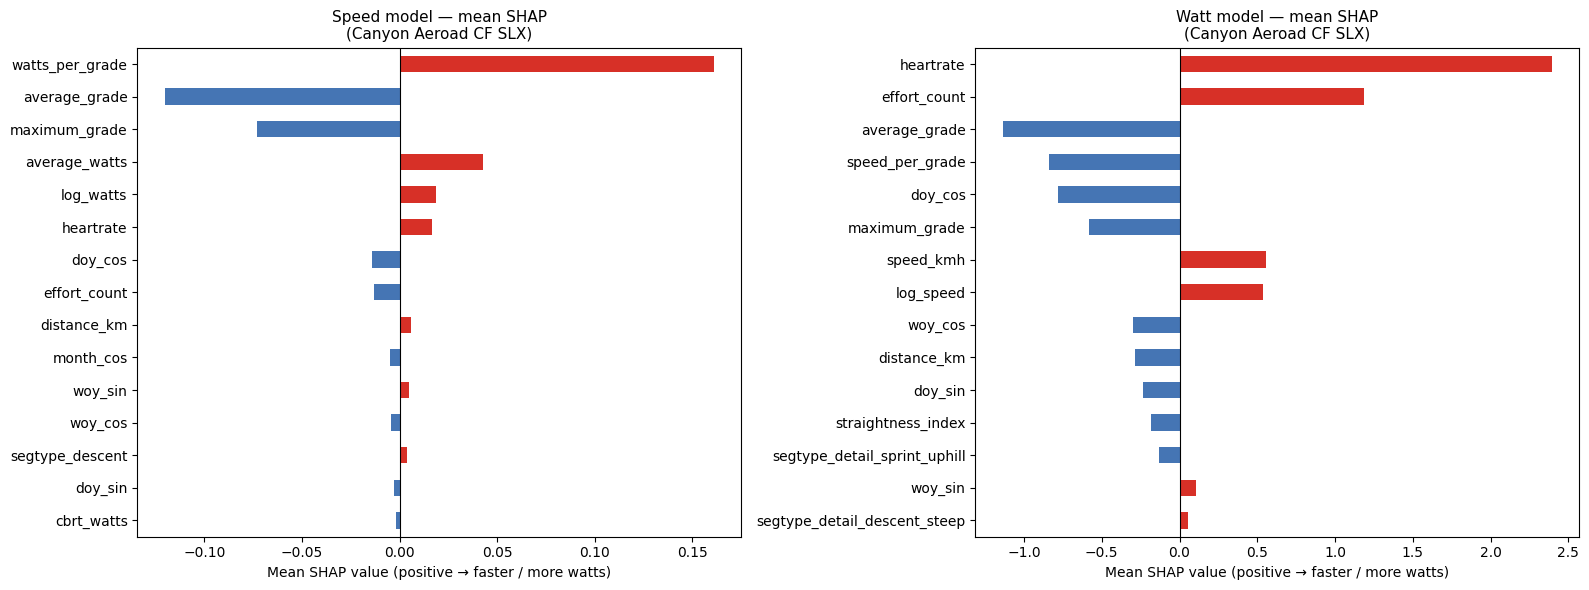

In [ ]:
import shap
import matplotlib.pyplot as plt

ref_bike = "Canyon Aeroad CF SLX"
print(f"SHAP analysis on: {ref_bike!r}")

# ── Speed model ───────────────────────────────────────────────────────────────
speed_sub = df[df["bike_name"] == ref_bike].dropna(subset=XGB_SPEED_FEATURES + ["speed_kmh"])
speed_model = fit_xgb_speed_model(speed_sub, ref_bike)
X_speed = speed_sub[XGB_SPEED_FEATURES]

speed_explainer = shap.TreeExplainer(speed_model)
speed_shap_vals = speed_explainer.shap_values(X_speed)

# ── Watt model ────────────────────────────────────────────────────────────────
watt_sub = df[df["bike_name"] == ref_bike].dropna(subset=XGB_WATT_FEATURES + ["average_watts"])
watt_model = fit_xgb_watt_model(watt_sub, ref_bike)
X_watt = watt_sub[XGB_WATT_FEATURES]

watt_explainer = shap.TreeExplainer(watt_model)
watt_shap_vals = watt_explainer.shap_values(X_watt)

# ── Waterfall-style summary: mean SHAP per feature (signed) ──────────────────
import numpy as np

def _shap_summary_bar(shap_vals, feature_names, ax, title, max_display=15):
    mean_shap = pd.Series(shap_vals.mean(axis=0), index=feature_names)
    mean_shap = mean_shap.reindex(mean_shap.abs().sort_values(ascending=False).index)
    mean_shap = mean_shap.iloc[:max_display].iloc[::-1]  # top N, smallest at top
    colors = ["#d73027" if v > 0 else "#4575b4" for v in mean_shap]
    mean_shap.plot.barh(ax=ax, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Mean SHAP value (positive → faster / more watts)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
_shap_summary_bar(speed_shap_vals, XGB_SPEED_FEATURES, axes[0], f"Speed model — mean SHAP\n({ref_bike})")
_shap_summary_bar(watt_shap_vals,  XGB_WATT_FEATURES,  axes[1], f"Watt model — mean SHAP\n({ref_bike})")
plt.tight_layout()
plt.show()